In [ ]:
# The following code will only execute
# successfully when compression is complete

import kagglehub

# Download latest version
path = kagglehub.dataset_download("hemsara21/plant-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plant-dataset' dataset.
Path to dataset files: /kaggle/input/plant-dataset


Image Processing

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

IMG_SIZE = 260
BATCH_SIZE = 32

data_dir = "/kaggle/input/plant-dataset/plant_dataset"

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = dataset.class_names
print(class_names)

# Normalize
normalization_layer = tf.keras.layers.Rescaling(1./255)

dataset = dataset.map(lambda x, y: (normalization_layer(x), y))

Found 2165 files belonging to 8 classes.
['Early Blight(Tomato)', 'Healthy Corn Plant', 'Healthy Potato Plant', 'Healthy Tomato Plant', 'Late Blight(Potato)', 'Leaf Blight(Corn)', 'Leaf Mold(Tomato)', 'Leaf Rust(Corn)']


Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.1),  # ~20 degrees
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.1),
])



  *Gaussian* noise (custom layer)

In [ ]:
class GaussianNoiseLayer(tf.keras.layers.Layer):
    def call(self, inputs, training=True):
        if training:
            noise = tf.random.normal(shape=tf.shape(inputs), mean=0.0, stddev=0.05)
            return inputs + noise
        return inputs

Train/Test Split

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(260, 260),
    batch_size=32
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(260, 260),
    batch_size=32
)

Found 2165 files belonging to 8 classes.
Using 1732 files for training.
Found 2165 files belonging to 8 classes.
Using 433 files for validation.


Prefetcher

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Model (EfficientNet-B3)

In [ ]:
import tensorflow as tf

# Load base model
base_model = tf.keras.applications.EfficientNetB3(
    input_shape=(260, 260, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

# Input layer
inputs = tf.keras.Input(shape=(260, 260, 3))

# Augmentation

x = data_augmentation(inputs)
x = GaussianNoiseLayer()(x)

# Preprocess for EfficientNet
x = tf.keras.applications.efficientnet.preprocess_input(x)

# Pass through base model
x = base_model(x, training=False)

# Classification head
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)

# Final model
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_layer_2          │ (None, 260, 260, 3)    │             0 │
│ (GaussianNoiseLayer)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 9, 9, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,185,207 (42.67 MB)

 Trainable params: 398,600 (1.52 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [ ]:
print(class_names)
print(len(class_names))

['Early Blight(Tomato)', 'Healthy Corn Plant', 'Healthy Potato Plant', 'Healthy Tomato Plant', 'Late Blight(Potato)', 'Leaf Blight(Corn)', 'Leaf Mold(Tomato)', 'Leaf Rust(Corn)']
8


Training

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3)
]

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 68s 822ms/step - accuracy: 0.8031 - loss: 0.5938 - val_accuracy: 0.8984 - val_loss: 0.3617 - learning_rate: 1.0000e-05
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 74s 700ms/step - accuracy: 0.8251 - loss: 0.4960 - val_accuracy: 0.8845 - val_loss: 0.4031 - learning_rate: 1.0000e-05
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 39s 704ms/step - accuracy: 0.8389 - loss: 0.4809 - val_accuracy: 0.8868 - val_loss: 0.4195 - learning_rate: 1.0000e-05
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 41s 703ms/step - accuracy: 0.8585 - loss: 0.4047 - val_accuracy: 0.8845 - val_loss: 0.4266 - learning_rate: 1.0000e-05
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 44s 753ms/step - accuracy: 0.8655 - loss: 0.3860 - val_accuracy: 0.8822 - val_loss: 0.4332 - learning_rate: 1.0000e-06
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 41s 738ms/step - accuracy: 0.8730 - loss: 0.3821 - val_accuracy: 0.8822 - val_loss: 0.4404 - learning_rate: 1.0000e-06


Fine-Tune Model

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

          *run model train again*

Accuracy Graph

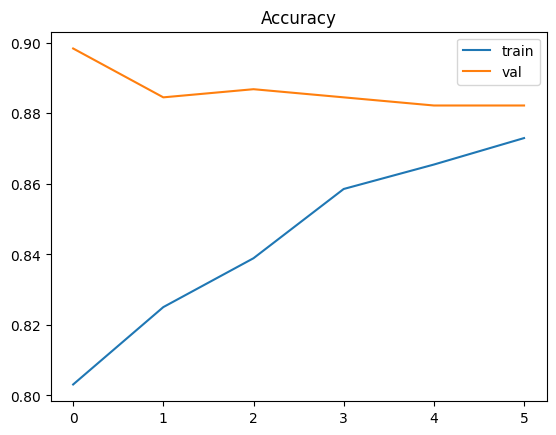

In [ ]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

Evaluation (F1 + Confusion Matrix)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
                      precision    recall  f1-score   support

Early Blight(Tomato)       0.88      0.86      0.87        49
  Healthy Corn Plant       0.94      0.95      0.94        62
Healthy Potato Plant       0.84      0.96      0.90        54
Healthy Tomato Plant       0.94      0.88      0.91        51
 Late Blight(Potato)       0.93      0.89      0.91        90
   Leaf Blight(Corn)       0.83      0.90      0.86        42
   Leaf Mold(Tomato)     

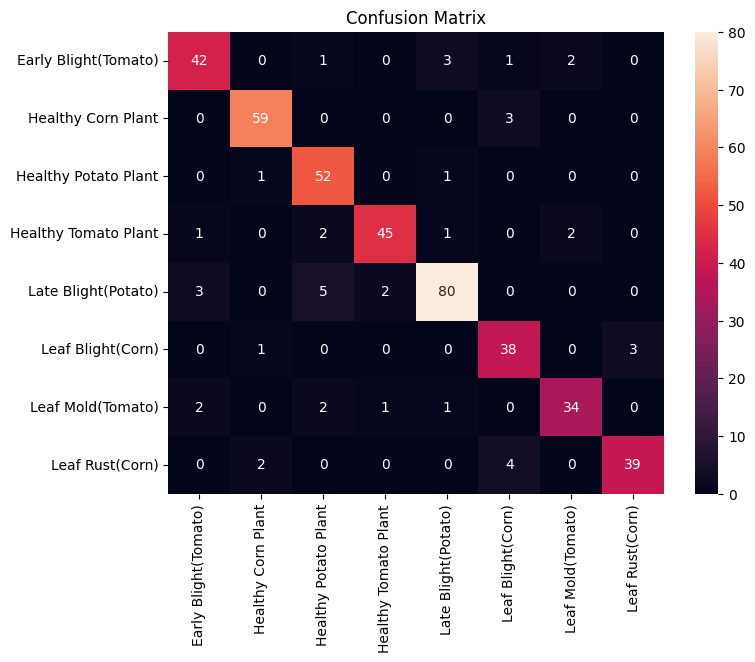

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.show()

Grad-CAM Heatmap

In [ ]:
import cv2

def get_heatmap(img, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img)
        loss = predictions[:, tf.argmax(predictions[0])]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)[0]
    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

    return heatmap

Save Model

In [ ]:
model.save("model.h5")

check prediction

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

# Recreate the custom layer
class GaussianNoiseLayer(tf.keras.layers.Layer):
    def call(self, inputs, training=True):
        if training:
            noise = tf.random.normal(shape=tf.shape(inputs), mean=0.0, stddev=0.05)
            return inputs + noise
        return inputs

# Load trained model
model = tf.keras.models.load_model(
    "model.h5",
    custom_objects={"GaussianNoiseLayer": GaussianNoiseLayer},
    compile=False
)

class_names = [
    "Early Blight(Tomato)",
    "Healthy Corn Plant",
    "Healthy Potato Plant",
    "Healthy Tomato Plant",
    "Late Blight(Potato)",
    "Leaf Blight(Corn)",
    "Leaf Mold(Tomato)",
    "Leaf Rust(Corn)"
]

IMG_SIZE = 260

def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)

    # Expand dimensions → (1, 260, 260, 3)
    img_array = np.expand_dims(img_array, axis=0)

    # EfficientNet preprocessing
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

    return img_array

def predict_image(img_path):
  img = preprocess_image(img_path)

  predictions = model.predict(img)[0]

  # Top prediction
  top_index = np.argmax(predictions)
  top_class = class_names[top_index]
  confidence = predictions[top_index]

  print(f"Prediction: {top_class}")
  print(f"Confidence: {confidence*100:.2f}%")

  return predictions

def top_predictions(predictions, top_n=4):
  indices = np.argsort(predictions)[-top_n:][::-1]

  results = []

  for i in indices:
      results.append({
          "class": class_names[i],
          "confidence": float(predictions[i])
      })

  return results

print("Model Loaded Successfully")


Model Loaded Successfully


In [ ]:
img_path = "/content/5nTXLbgT69qWcndC7vk6TH.jpg"

preds = predict_image(img_path)
top4 = top_predictions(preds)

print("\nTop 4 Predictions:")
for item in top4:
    print(f"{item['class']} → {item['confidence']*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Prediction: Healthy Potato Plant
Confidence: 99.31%

Top 4 Predictions:
Healthy Potato Plant → 99.31%
Late Blight(Potato) → 0.54%
Healthy Tomato Plant → 0.15%
Leaf Mold(Tomato) → 0.00%
